In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [22]:
data = pd.read_csv(r"\Users\annec\Python_DeCal_Fa2025\course_assignments\homework9\solar_system.csv")
df = pd.DataFrame(data)

In [3]:
df.shape # 20, 11
# 20 rows, 11 columns

(20, 11)

In [4]:
df.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [5]:
df.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [6]:
print(df.columns)

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [7]:
print(df["Attribute"])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [8]:
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
# perihelion: the point where a planet's orbit is closest to its star
# aphelion: the point where a planet's orbit is farthest from its star
# semi-major axis: the longest axis of an ellipse divided by 2

In [9]:
semi_major_axis = (perihelion + aphelion) / 2

In [23]:
series = pd.Series(semi_major_axis)
df = pd.concat([df, series.to_frame().T], ignore_index = True)
df.loc[20, "Attribute"] = "Semi-major Axis (10^6 km)"
df

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [25]:
df.shape # 21 rows, 11 columns

(21, 11)

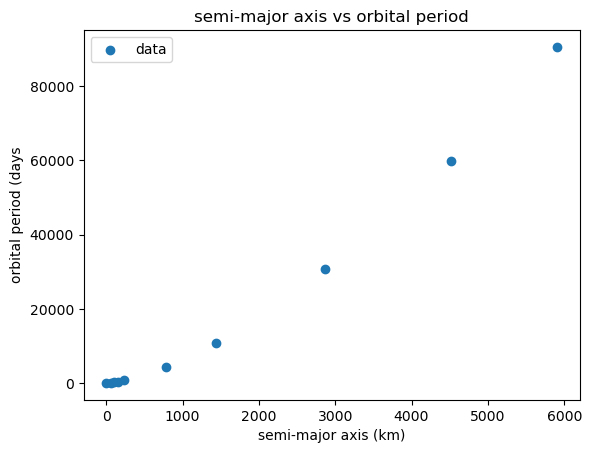

In [27]:
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label = "data")
plt.xlabel("semi-major axis (km)")
plt.ylabel("orbital period (days")
plt.title("semi-major axis vs orbital period")
plt.legend()
plt.show()

In [38]:
def keplers_third_law(a, m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=0)

m_fit = popt[0]

print(f"Fit: y = {m_fit:.2f}*a^1.5")

residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = (chi2 / dof)

print(f"{chi2_reduced:.2f}")

Fit: y = 0.20*a^1.5
41276.71


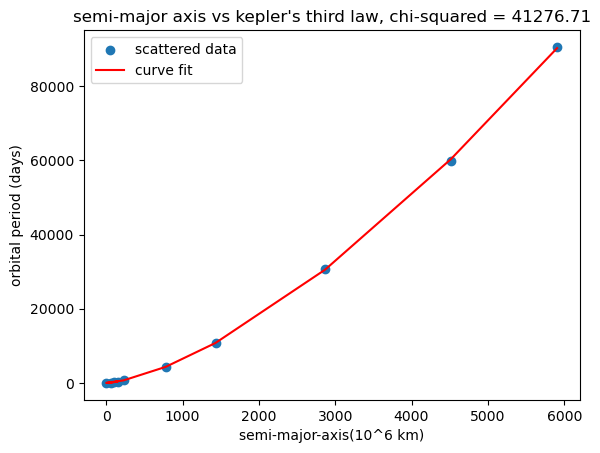

In [44]:
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label = "scattered data")
plt.plot(semi_major_axis, keplers_third_law(semi_major_axis, m_fit), color = "red", label = "curve fit")
plt.title(f"semi-major axis vs kepler's third law, chi-squared = {chi2_reduced:.2f}")
plt.legend()
plt.xlabel("semi-major-axis(10^6 km)")
plt.ylabel("orbital period (days)")
plt.show()

In [45]:
df.to_csv("kepler.csv", index=False)